# Assignment 8: Variational Autoencoder and Its 2D Latent Space
**Name:** Varshith Kumar R
**Class:** BCA

**Aim:** To train a normal autoencoder and a Variational Autoencoder (VAE) on the MNIST handwritten digit dataset, using a 2-dimensional latent space, and to study how the two models organise the digits in that space.


## Step 1: Import Libraries and Fix the Random Seed

In [1]:
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

SEED = 7
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Random seed :", SEED)
print("Device      :", DEVICE)
print("PyTorch     :", torch.__version__)

Random seed : 7
Device      : cpu
PyTorch     : 2.14.0+cu130


## Step 2: Load the MNIST Dataset

MNIST has 60,000 training images and 10,000 test images of handwritten digits. Each image is 28 x 28 pixels in grayscale. The pixel values are scaled to the range 0 to 1 by `ToTensor`.

In [2]:
BATCH_SIZE = 100

to_tensor = transforms.ToTensor()

train_set = torchvision.datasets.MNIST(root="./data", train=True, download=True, transform=to_tensor)
test_set = torchvision.datasets.MNIST(root="./data", train=False, download=True, transform=to_tensor)

shuffle_gen = torch.Generator().manual_seed(SEED)
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, generator=shuffle_gen)
test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False)

print("Training images :", len(train_set))
print("Test images     :", len(test_set))
print("Image shape     :", tuple(train_set[0][0].shape))
print("Batches per epoch (train):", len(train_loader))

Training images : 60000
Test images     : 10000
Image shape     : (1, 28, 28)
Batches per epoch (train): 600


## Step 3: Look at Some MNIST Images

A few random training images are shown along with their labels before any model is trained.

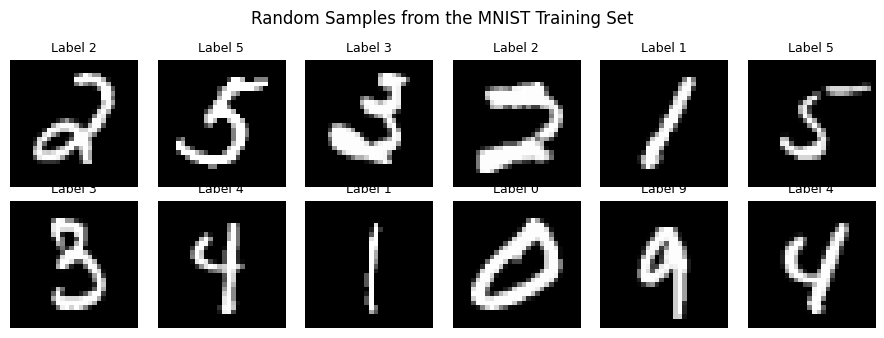

In [3]:
preview_idx = torch.randperm(len(train_set), generator=torch.Generator().manual_seed(SEED))[:12]

fig, axes = plt.subplots(2, 6, figsize=(9, 3.4))
for ax, idx in zip(axes.ravel(), preview_idx):
    img, lab = train_set[int(idx)]
    ax.imshow(img.squeeze(), cmap="gray")
    ax.set_title(f"Label {lab}", fontsize=9)
    ax.axis("off")
fig.suptitle("Random Samples from the MNIST Training Set", fontsize=12)
plt.tight_layout()
plt.show()

## Step 4: Normal Autoencoder

A normal autoencoder has an encoder that squeezes each image into a small code, and a decoder that rebuilds the image from that code. Here the code has only 2 numbers, so it can be drawn on a flat plot. The last layer of the decoder is a Sigmoid so that outputs stay between 0 and 1, the same as the pixel values.

In [4]:
class PlainAutoencoder(nn.Module):
    def __init__(self, hidden_a=512, hidden_b=128, code_size=2):
        super().__init__()
        self.enc = nn.Sequential(
            nn.Linear(28 * 28, hidden_a),
            nn.LeakyReLU(0.1),
            nn.Linear(hidden_a, hidden_b),
            nn.LeakyReLU(0.1),
            nn.Linear(hidden_b, code_size),
        )
        self.dec = nn.Sequential(
            nn.Linear(code_size, hidden_b),
            nn.LeakyReLU(0.1),
            nn.Linear(hidden_b, hidden_a),
            nn.LeakyReLU(0.1),
            nn.Linear(hidden_a, 28 * 28),
            nn.Sigmoid(),
        )

    def forward(self, x):
        code = self.enc(x.flatten(1))
        return self.dec(code), code


plain_ae = PlainAutoencoder().to(DEVICE)
print(plain_ae)
n_params_ae = sum(p.numel() for p in plain_ae.parameters())
print("\nTrainable parameters:", f"{n_params_ae:,}")

PlainAutoencoder(
  (enc): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): LeakyReLU(negative_slope=0.1)
    (2): Linear(in_features=512, out_features=128, bias=True)
    (3): LeakyReLU(negative_slope=0.1)
    (4): Linear(in_features=128, out_features=2, bias=True)
  )
  (dec): Sequential(
    (0): Linear(in_features=2, out_features=128, bias=True)
    (1): LeakyReLU(negative_slope=0.1)
    (2): Linear(in_features=128, out_features=512, bias=True)
    (3): LeakyReLU(negative_slope=0.1)
    (4): Linear(in_features=512, out_features=784, bias=True)
    (5): Sigmoid()
  )
)

Trainable parameters: 936,466


## Step 5: Train the Normal Autoencoder

The autoencoder is trained for 12 epochs with the Adam optimiser and the binary cross entropy loss between the input image and its reconstruction.

In [5]:
AE_EPOCHS = 12
AE_LR = 1.5e-3

ae_optim = torch.optim.Adam(plain_ae.parameters(), lr=AE_LR)
ae_history = []

for epoch in range(1, AE_EPOCHS + 1):
    plain_ae.train()
    running = 0.0
    for batch, _ in train_loader:
        batch = batch.to(DEVICE)
        recon, _ = plain_ae(batch)
        loss = F.binary_cross_entropy(recon, batch.flatten(1))
        ae_optim.zero_grad()
        loss.backward()
        ae_optim.step()
        running += loss.item()
    ae_history.append(running / len(train_loader))
    print(f"Epoch {epoch:02d}/{AE_EPOCHS}  |  Autoencoder BCE loss: {ae_history[-1]:.4f}")

Epoch 01/12  |  Autoencoder BCE loss: 0.2171


Epoch 02/12  |  Autoencoder BCE loss: 0.1933


Epoch 03/12  |  Autoencoder BCE loss: 0.1875


Epoch 04/12  |  Autoencoder BCE loss: 0.1838


Epoch 05/12  |  Autoencoder BCE loss: 0.1816


...

Epoch 08/12  |  Autoencoder BCE loss: 0.1771


Epoch 09/12  |  Autoencoder BCE loss: 0.1758


Epoch 10/12  |  Autoencoder BCE loss: 0.1751


Epoch 11/12  |  Autoencoder BCE loss: 0.1743


Epoch 12/12  |  Autoencoder BCE loss: 0.1735


## Step 6: Latent Space of the Normal Autoencoder

All 10,000 test images are passed through the trained encoder. Each image gives one point in 2D, and the point is coloured by the true digit.

Range of latent dimension 1 : -17.87 to 24.08
Range of latent dimension 2 : -17.78 to 13.45


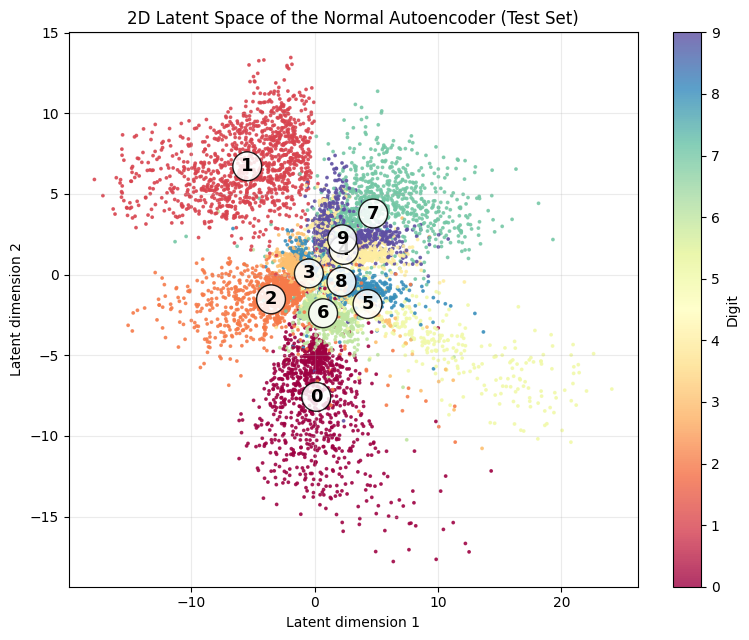

In [6]:
@torch.no_grad()
def gather_codes(encode_fn, loader):
    codes, labels = [], []
    for batch, lab in loader:
        codes.append(encode_fn(batch.to(DEVICE)).cpu())
        labels.append(lab)
    return torch.cat(codes).numpy(), torch.cat(labels).numpy()


def draw_latent_plot(points, labels, title):
    fig, ax = plt.subplots(figsize=(8, 6.5))
    sc = ax.scatter(points[:, 0], points[:, 1], c=labels, cmap="Spectral", s=3, alpha=0.8)
    cbar = fig.colorbar(sc, ax=ax, ticks=range(10))
    cbar.set_label("Digit")
    for d in range(10):
        centre = points[labels == d].mean(axis=0)
        ax.text(centre[0], centre[1], str(d), fontsize=13, fontweight="bold",
                ha="center", va="center", bbox=dict(boxstyle="circle", fc="white", ec="black", alpha=0.85))
    ax.set_title(title)
    ax.set_xlabel("Latent dimension 1")
    ax.set_ylabel("Latent dimension 2")
    ax.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()


plain_ae.eval()
ae_points, ae_labels = gather_codes(lambda x: plain_ae(x)[1], test_loader)

print("Range of latent dimension 1 : %.2f to %.2f" % (ae_points[:, 0].min(), ae_points[:, 0].max()))
print("Range of latent dimension 2 : %.2f to %.2f" % (ae_points[:, 1].min(), ae_points[:, 1].max()))

draw_latent_plot(ae_points, ae_labels, "2D Latent Space of the Normal Autoencoder (Test Set)")

## Step 7: Variational Autoencoder (VAE)

A VAE does not map an image to a single point. The encoder outputs a **mean** and a **log variance** for each latent dimension, which describe a small Gaussian distribution. A point `z` is then sampled from this distribution using the reparameterisation trick:

`z = mu + sigma * epsilon`, where `epsilon` is random noise from a standard normal distribution.

This keeps the sampling step differentiable, so the network can still be trained with back-propagation. The decoder rebuilds the image from `z`.

The VAE below is slightly different from the plain autoencoder: it has a shared encoder body with two separate output heads (one for the mean and one for the log variance), and the hidden layers use a wider first layer with layer normalisation.

In [7]:
class GaussianVAE(nn.Module):
    def __init__(self, hidden_a=512, hidden_b=128, code_size=2):
        super().__init__()
        self.body = nn.Sequential(
            nn.Linear(28 * 28, hidden_a),
            nn.LayerNorm(hidden_a),
            nn.LeakyReLU(0.1),
            nn.Linear(hidden_a, hidden_b),
            nn.LeakyReLU(0.1),
        )
        self.head_mean = nn.Linear(hidden_b, code_size)
        self.head_logvar = nn.Linear(hidden_b, code_size)
        self.decoder = nn.Sequential(
            nn.Linear(code_size, hidden_b),
            nn.LeakyReLU(0.1),
            nn.Linear(hidden_b, hidden_a),
            nn.LeakyReLU(0.1),
            nn.Linear(hidden_a, 28 * 28),
            nn.Sigmoid(),
        )

    def encode(self, x):
        h = self.body(x.flatten(1))
        return self.head_mean(h), self.head_logvar(h)

    def sample(self, mean, logvar):
        sigma = torch.exp(0.5 * logvar)
        noise = torch.randn_like(sigma)
        return mean + noise * sigma

    def forward(self, x):
        mean, logvar = self.encode(x)
        z = self.sample(mean, logvar)
        return self.decoder(z), mean, logvar


vae_model = GaussianVAE().to(DEVICE)
print(vae_model)
n_params_vae = sum(p.numel() for p in vae_model.parameters())
print("\nTrainable parameters:", f"{n_params_vae:,}")

GaussianVAE(
  (body): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): LayerNorm((512,), eps=1e-05, elementwise_affine=True, bias=True)
    (2): LeakyReLU(negative_slope=0.1)
    (3): Linear(in_features=512, out_features=128, bias=True)
    (4): LeakyReLU(negative_slope=0.1)
  )
  (head_mean): Linear(in_features=128, out_features=2, bias=True)
  (head_logvar): Linear(in_features=128, out_features=2, bias=True)
  (decoder): Sequential(
    (0): Linear(in_features=2, out_features=128, bias=True)
    (1): LeakyReLU(negative_slope=0.1)
    (2): Linear(in_features=128, out_features=512, bias=True)
    (3): LeakyReLU(negative_slope=0.1)
    (4): Linear(in_features=512, out_features=784, bias=True)
    (5): Sigmoid()
  )
)

Trainable parameters: 937,748


## Step 8: VAE Loss Function

The VAE loss has two parts:

- **Reconstruction loss:** the sum of squared differences between the original and the reconstructed pixels. It pushes the decoder to rebuild the image well.
- **KL divergence:** measures how far each learned Gaussian is from the standard normal distribution N(0, 1). It pushes all the encoded distributions to stay close to the centre and to overlap, which gives a smooth latent space.

The total loss is the sum of the two parts. Losses are reported per image so they are easy to compare across epochs.

In [8]:
def vae_objective(recon, target, mean, logvar):
    recon_term = F.mse_loss(recon, target.flatten(1), reduction="sum")
    kl_term = -0.5 * torch.sum(1 + logvar - mean.pow(2) - logvar.exp())
    return recon_term + kl_term, recon_term, kl_term


def run_vae_epoch(model, loader, optimiser=None):
    training = optimiser is not None
    model.train(training)
    sums = np.zeros(3)
    seen = 0
    with torch.set_grad_enabled(training):
        for batch, _ in loader:
            batch = batch.to(DEVICE)
            recon, mean, logvar = model(batch)
            total, rec, kl = vae_objective(recon, batch, mean, logvar)
            if training:
                optimiser.zero_grad()
                total.backward()
                optimiser.step()
            sums += np.array([total.item(), rec.item(), kl.item()])
            seen += batch.size(0)
    return sums / seen


print("Loss functions defined.")

Loss functions defined.


## Step 9: Train the VAE

The VAE is trained for 25 epochs. After every epoch the total, reconstruction and KL losses are recorded for the training set, and the total loss is also measured on the test set so that overfitting can be checked.

In [9]:
VAE_EPOCHS = 25
VAE_LR = 1e-3

vae_optim = torch.optim.Adam(vae_model.parameters(), lr=VAE_LR)
vae_sched = torch.optim.lr_scheduler.StepLR(vae_optim, step_size=10, gamma=0.5)

hist = {"total": [], "recon": [], "kl": [], "test_total": []}

for epoch in range(1, VAE_EPOCHS + 1):
    tr_total, tr_rec, tr_kl = run_vae_epoch(vae_model, train_loader, vae_optim)
    te_total, _, _ = run_vae_epoch(vae_model, test_loader)
    vae_sched.step()
    hist["total"].append(tr_total)
    hist["recon"].append(tr_rec)
    hist["kl"].append(tr_kl)
    hist["test_total"].append(te_total)
    print(f"Epoch {epoch:02d}/{VAE_EPOCHS}  |  total {tr_total:7.3f}  |  recon {tr_rec:7.3f}  |  KL {tr_kl:6.3f}  |  test total {te_total:7.3f}")

Epoch 01/25  |  total  46.063  |  recon  43.107  |  KL  2.956  |  test total  40.876


Epoch 02/25  |  total  40.267  |  recon  36.464  |  KL  3.803  |  test total  39.351


Epoch 03/25  |  total  39.018  |  recon  34.890  |  KL  4.128  |  test total  38.258


Epoch 04/25  |  total  38.117  |  recon  33.755  |  KL  4.362  |  test total  37.572


Epoch 05/25  |  total  37.492  |  recon  32.976  |  KL  4.516  |  test total  37.083


...

Epoch 21/25  |  total  34.104  |  recon  28.896  |  KL  5.209  |  test total  34.621


Epoch 22/25  |  total  34.039  |  recon  28.808  |  KL  5.231  |  test total  34.591


Epoch 23/25  |  total  34.007  |  recon  28.757  |  KL  5.250  |  test total  34.582


Epoch 24/25  |  total  33.967  |  recon  28.705  |  KL  5.262  |  test total  34.559


Epoch 25/25  |  total  33.929  |  recon  28.667  |  KL  5.262  |  test total  34.654


## Step 10: Loss Curves

The first figure shows the loss of the normal autoencoder. The second figure shows the three VAE loss curves separately, together with a comparison of the training and test total loss.

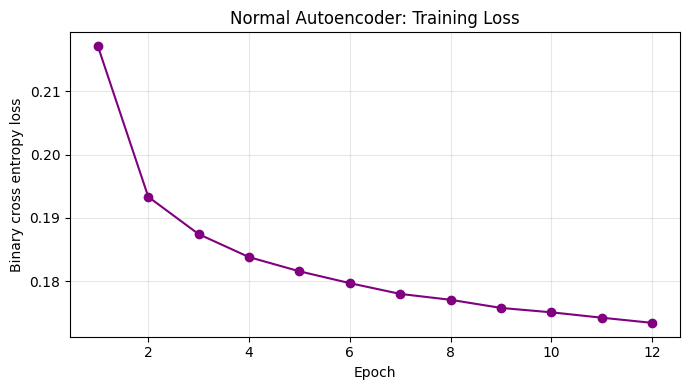

In [10]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(1, AE_EPOCHS + 1), ae_history, marker="o", color="purple")
ax.set_title("Normal Autoencoder: Training Loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Binary cross entropy loss")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

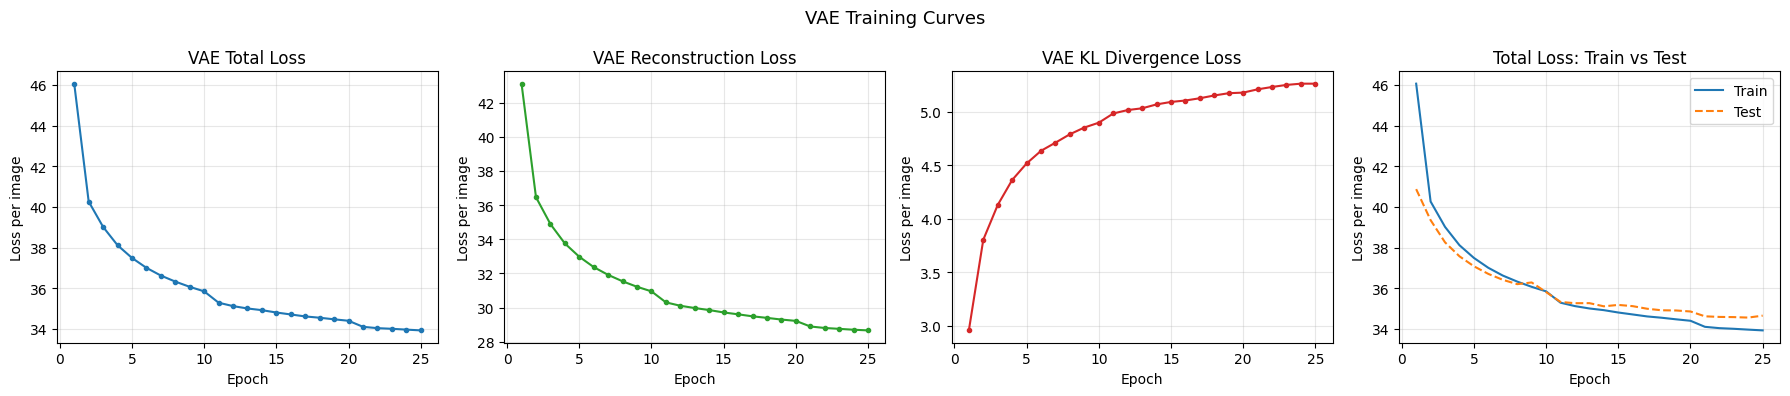

First epoch  -> total 46.063, recon 43.107, KL 2.956
Last epoch   -> total 33.929, recon 28.667, KL 5.262
Lowest KL was 2.956 at epoch 1
Highest KL was 5.262 at epoch 25


In [11]:
epochs_axis = range(1, VAE_EPOCHS + 1)
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

axes[0].plot(epochs_axis, hist["total"], color="tab:blue", marker="o", ms=3)
axes[0].set_title("VAE Total Loss")

axes[1].plot(epochs_axis, hist["recon"], color="tab:green", marker="o", ms=3)
axes[1].set_title("VAE Reconstruction Loss")

axes[2].plot(epochs_axis, hist["kl"], color="tab:red", marker="o", ms=3)
axes[2].set_title("VAE KL Divergence Loss")

axes[3].plot(epochs_axis, hist["total"], label="Train", color="tab:blue")
axes[3].plot(epochs_axis, hist["test_total"], label="Test", color="tab:orange", linestyle="--")
axes[3].set_title("Total Loss: Train vs Test")
axes[3].legend()

for ax in axes:
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss per image")
    ax.grid(alpha=0.3)

plt.suptitle("VAE Training Curves", fontsize=13)
plt.tight_layout()
plt.show()

print(f"First epoch  -> total {hist['total'][0]:.3f}, recon {hist['recon'][0]:.3f}, KL {hist['kl'][0]:.3f}")
print(f"Last epoch   -> total {hist['total'][-1]:.3f}, recon {hist['recon'][-1]:.3f}, KL {hist['kl'][-1]:.3f}")
print(f"Lowest KL was {min(hist['kl']):.3f} at epoch {int(np.argmin(hist['kl'])) + 1}")
print(f"Highest KL was {max(hist['kl']):.3f} at epoch {int(np.argmax(hist['kl'])) + 1}")

## Step 11: Reconstruction Test

The first ten test images are shown in the top row. The middle row shows what the VAE rebuilds from a sampled latent point, and the bottom row shows the absolute difference between the two.

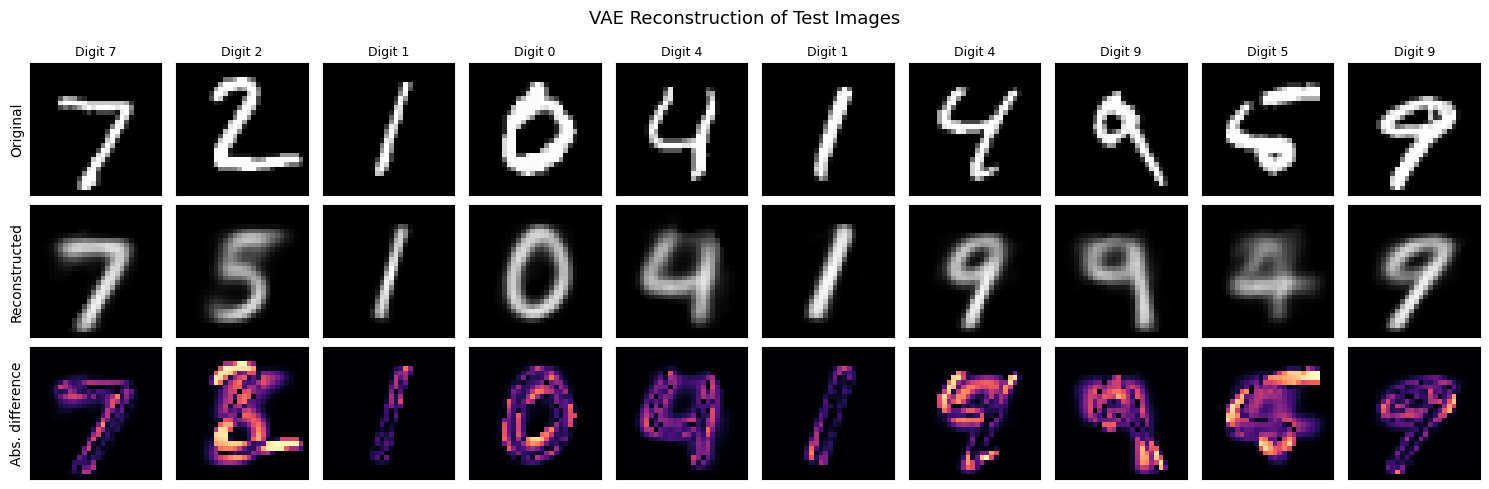

Mean absolute pixel error on these 10 images: 0.0882


In [12]:
vae_model.eval()
sample_batch, sample_labels = next(iter(test_loader))
sample_batch = sample_batch[:10].to(DEVICE)

with torch.no_grad():
    rebuilt, _, _ = vae_model(sample_batch)

originals = sample_batch.cpu().squeeze(1).numpy()
rebuilt = rebuilt.cpu().view(-1, 28, 28).numpy()
difference = np.abs(originals - rebuilt)

fig, axes = plt.subplots(3, 10, figsize=(15, 5))
row_names = ["Original", "Reconstructed", "Abs. difference"]
for col in range(10):
    for row, (data, cmap) in enumerate([(originals, "gray"), (rebuilt, "gray"), (difference, "magma")]):
        axes[row, col].imshow(data[col], cmap=cmap, vmin=0, vmax=1)
        axes[row, col].set_xticks([])
        axes[row, col].set_yticks([])
        if col == 0:
            axes[row, col].set_ylabel(row_names[row], fontsize=10)
    axes[0, col].set_title(f"Digit {int(sample_labels[col])}", fontsize=9)
fig.suptitle("VAE Reconstruction of Test Images", fontsize=13)
plt.tight_layout()
plt.show()

print("Mean absolute pixel error on these 10 images: %.4f" % difference.mean())

## Step 12: Latent Space of the VAE

The mean vector produced by the VAE encoder is used as the position of each test image. The plot uses the same colours and the same style as Step 6 so that the two latent spaces can be compared directly. Centres of each digit are marked with numbers.

Range of latent dimension 1 : -3.92 to 3.71
Range of latent dimension 2 : -3.81 to 3.19
Mean of the points          : (0.00, -0.01)
Standard deviation          : (1.03, 1.05)


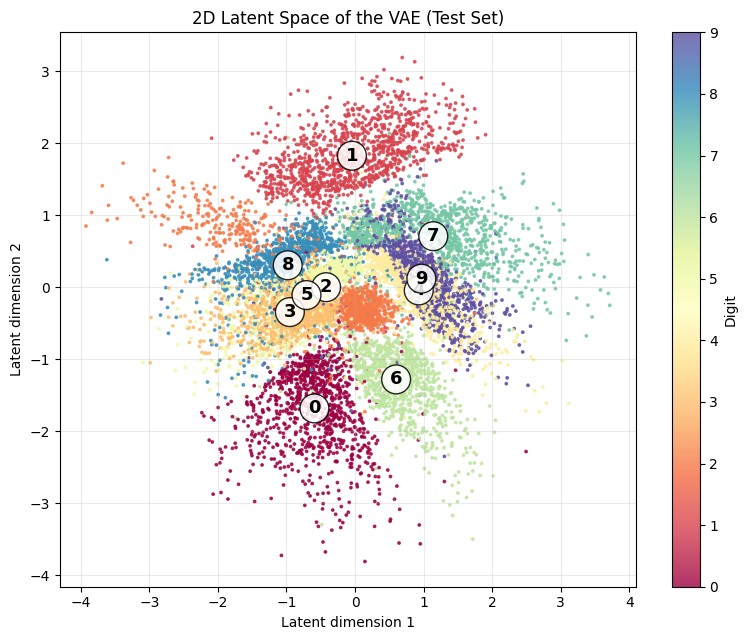

In [13]:
vae_model.eval()
vae_points, vae_labels = gather_codes(lambda x: vae_model.encode(x)[0], test_loader)

print("Range of latent dimension 1 : %.2f to %.2f" % (vae_points[:, 0].min(), vae_points[:, 0].max()))
print("Range of latent dimension 2 : %.2f to %.2f" % (vae_points[:, 1].min(), vae_points[:, 1].max()))
print("Mean of the points          : (%.2f, %.2f)" % tuple(vae_points.mean(axis=0)))
print("Standard deviation          : (%.2f, %.2f)" % tuple(vae_points.std(axis=0)))

draw_latent_plot(vae_points, vae_labels, "2D Latent Space of the VAE (Test Set)")

### Measuring How Well the Digits Are Grouped

To support the visual comparison with numbers, a simple 5-nearest-neighbour classifier is used. The 10,000 test points are split into two halves. One half is used as the reference set, and each point in the other half is given the majority label of its 5 closest reference points. The higher the accuracy, the better the digit classes are grouped in the 2D latent space.

In [14]:
def knn_accuracy(points, labels, k=5, seed=SEED):
    rng = np.random.RandomState(seed)
    order = rng.permutation(len(points))
    half = len(points) // 2
    ref_idx, qry_idx = order[:half], order[half:]
    ref = torch.tensor(points[ref_idx], dtype=torch.float32)
    qry = torch.tensor(points[qry_idx], dtype=torch.float32)
    ref_lab = torch.tensor(labels[ref_idx])
    dist = torch.cdist(qry, ref)
    nearest = dist.topk(k, largest=False).indices
    votes = ref_lab[nearest]
    predicted = torch.mode(votes, dim=1).values
    return (predicted.numpy() == labels[qry_idx]).mean()


def centre_spread(points, labels):
    centres = np.stack([points[labels == d].mean(axis=0) for d in range(10)])
    dist = np.linalg.norm(centres[:, None] - centres[None], axis=-1)
    return dist[np.triu_indices(10, 1)].mean()


ae_acc = knn_accuracy(ae_points, ae_labels)
vae_acc = knn_accuracy(vae_points, vae_labels)

print(f"{'Model':<22}{'5-NN accuracy':>15}{'Avg. distance between digit centres':>40}")
print(f"{'Normal autoencoder':<22}{ae_acc:>15.3f}{centre_spread(ae_points, ae_labels):>40.2f}")
print(f"{'VAE':<22}{vae_acc:>15.3f}{centre_spread(vae_points, vae_labels):>40.2f}")

print("\nDigit centres in the VAE latent space:")
for d in range(10):
    c = vae_points[vae_labels == d].mean(axis=0)
    print(f"  digit {d}: ({c[0]:6.2f}, {c[1]:6.2f})")

Model                   5-NN accuracy     Avg. distance between digit centres
Normal autoencoder              0.773                                    6.35
VAE                             0.799                                    1.67

Digit centres in the VAE latent space:
  digit 0: ( -0.59,  -1.68)
  digit 1: ( -0.04,   1.83)
  digit 2: ( -0.42,   0.00)
  digit 3: ( -0.95,  -0.34)
  digit 4: (  0.93,  -0.04)
  digit 5: ( -0.71,  -0.11)
  digit 6: (  0.60,  -1.28)
  digit 7: (  1.14,   0.71)
  digit 8: ( -0.98,   0.31)
  digit 9: (  0.97,   0.12)


## Step 13: Decoded Grid of the Latent Space

A 15 x 15 grid of points is placed between -3 and +3 on both latent axes. Each point is given to the VAE decoder and the resulting images are joined into one large picture. Moving across the picture is the same as moving across the latent space.

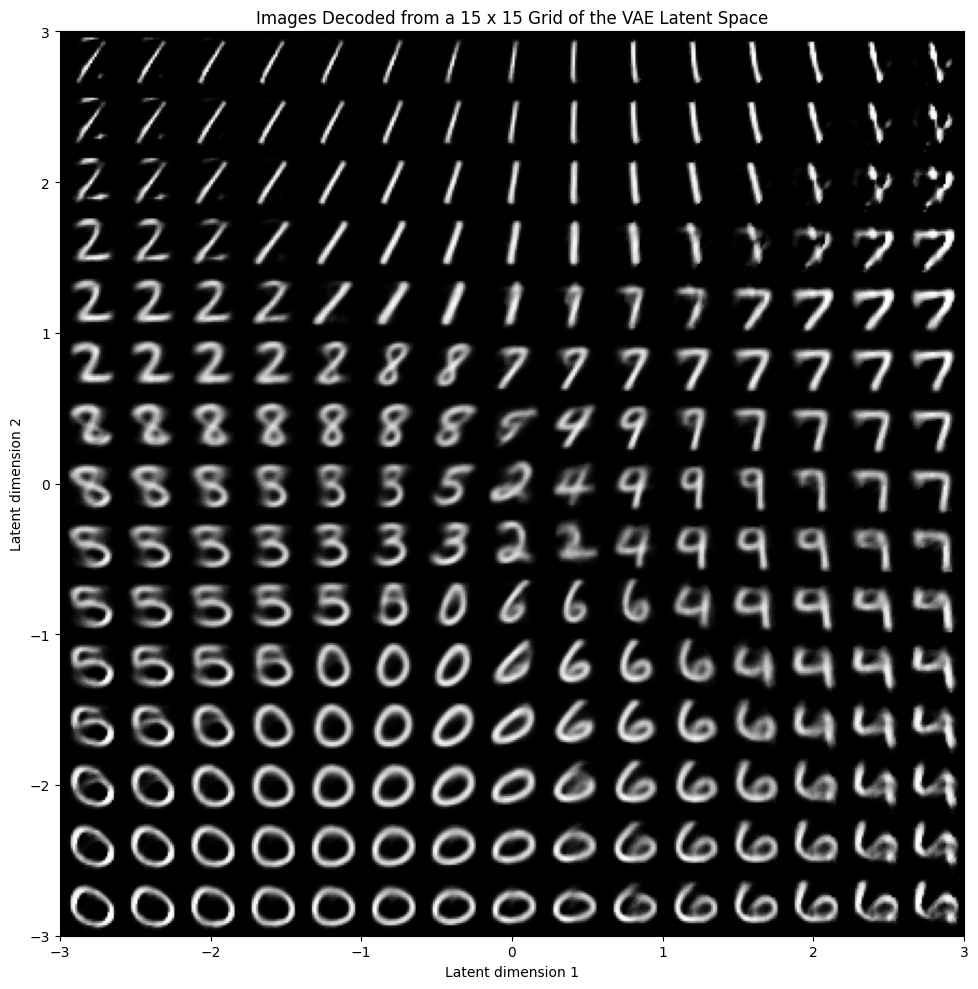

In [15]:
GRID_N = 15
GRID_LIM = 3.0

xs = torch.linspace(-GRID_LIM, GRID_LIM, GRID_N)
ys = torch.linspace(GRID_LIM, -GRID_LIM, GRID_N)
mesh_y, mesh_x = torch.meshgrid(ys, xs, indexing="ij")
grid_codes = torch.stack([mesh_x.flatten(), mesh_y.flatten()], dim=1).to(DEVICE)

with torch.no_grad():
    grid_imgs = vae_model.decoder(grid_codes).cpu().view(GRID_N, GRID_N, 28, 28)

canvas = grid_imgs.permute(0, 2, 1, 3).reshape(GRID_N * 28, GRID_N * 28).numpy()

fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(canvas, cmap="gray", extent=[-GRID_LIM, GRID_LIM, -GRID_LIM, GRID_LIM])
ax.set_title("Images Decoded from a 15 x 15 Grid of the VAE Latent Space")
ax.set_xlabel("Latent dimension 1")
ax.set_ylabel("Latent dimension 2")
plt.tight_layout()
plt.show()

### The Same Grid Drawn Over the Latent Scatter Plot

The decoded grid is drawn beside the scatter plot of the test digits, using the same axis limits, so it is easier to see which digit is decoded in which region.

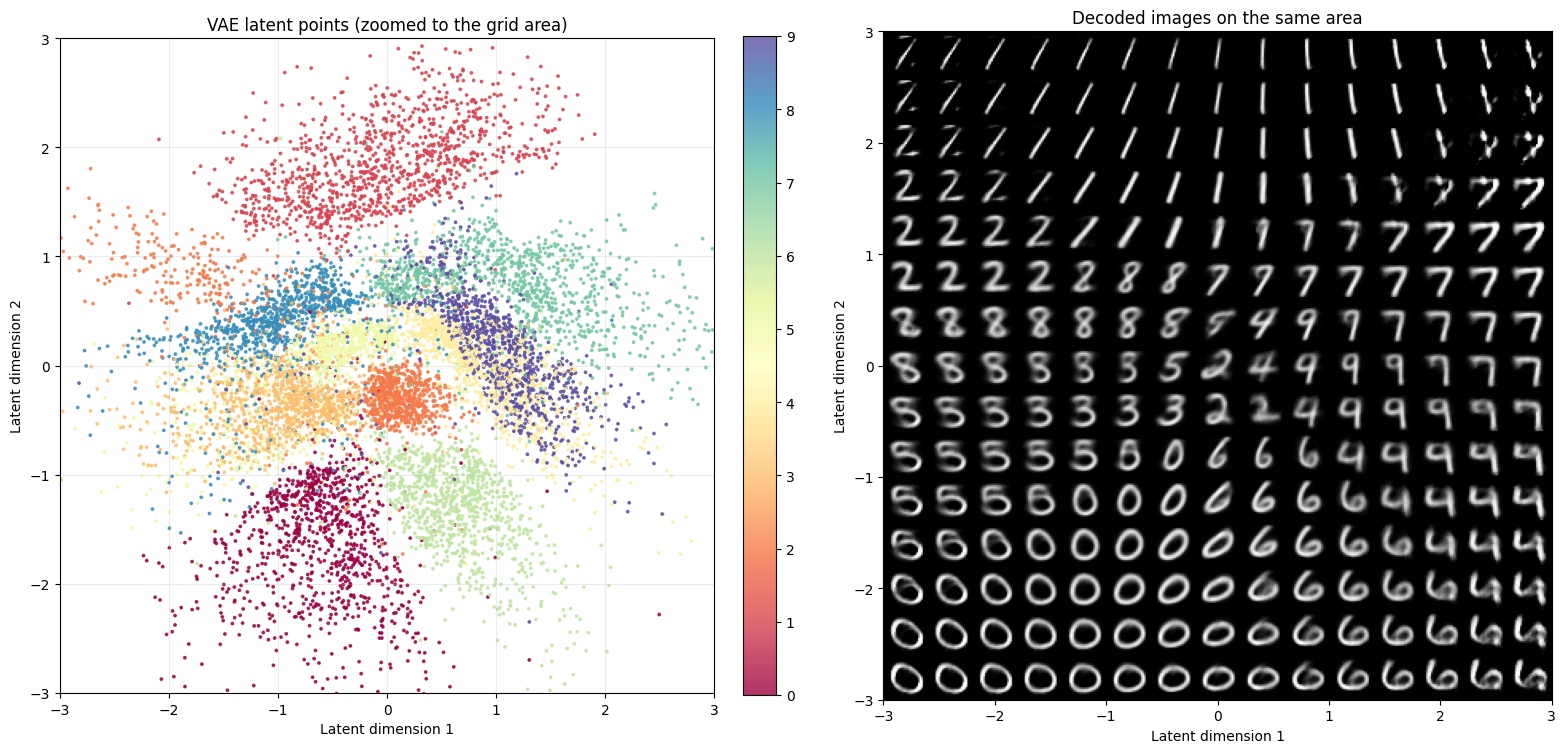

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7.5))

sc = axes[0].scatter(vae_points[:, 0], vae_points[:, 1], c=vae_labels, cmap="Spectral", s=3, alpha=0.8)
axes[0].set_xlim(-GRID_LIM, GRID_LIM)
axes[0].set_ylim(-GRID_LIM, GRID_LIM)
axes[0].set_title("VAE latent points (zoomed to the grid area)")
axes[0].set_xlabel("Latent dimension 1")
axes[0].set_ylabel("Latent dimension 2")
axes[0].set_aspect("equal")
axes[0].grid(alpha=0.25)
fig.colorbar(sc, ax=axes[0], ticks=range(10), fraction=0.046, pad=0.04)

axes[1].imshow(canvas, cmap="gray", extent=[-GRID_LIM, GRID_LIM, -GRID_LIM, GRID_LIM])
axes[1].set_title("Decoded images on the same area")
axes[1].set_xlabel("Latent dimension 1")
axes[1].set_ylabel("Latent dimension 2")

plt.tight_layout()
plt.show()

## Step 14: Images from Extreme Latent Points

Points near and beyond the edge of the region that contains the training data are decoded, to see how the decoder behaves at the boundaries of the latent space.

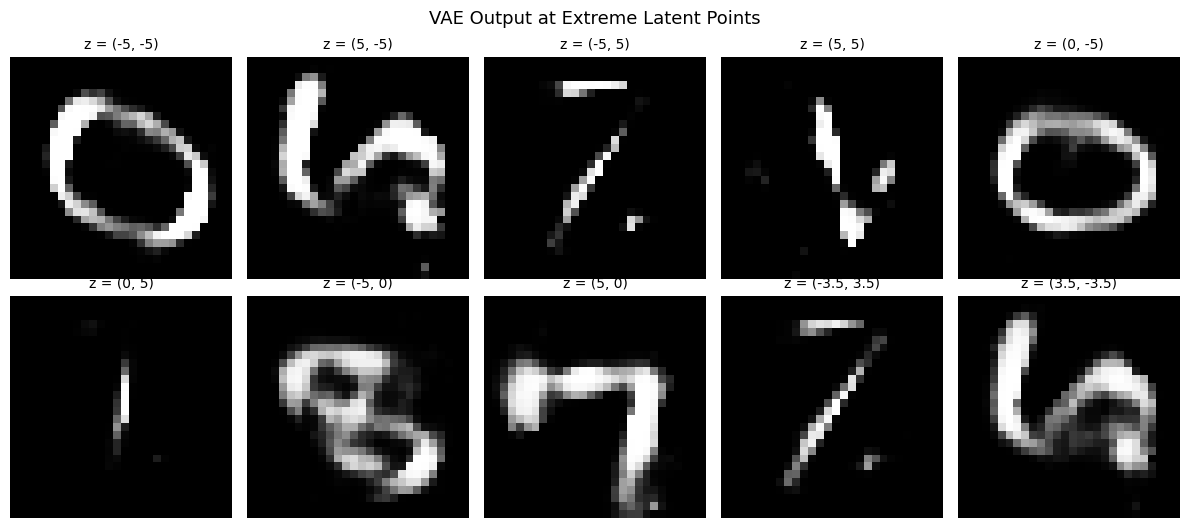

z = (-5, -5)     mean pixel = 0.1421   max pixel = 1.0000
z = (5, -5)      mean pixel = 0.1645   max pixel = 1.0000
z = (-5, 5)      mean pixel = 0.0380   max pixel = 1.0000
z = (5, 5)       mean pixel = 0.0555   max pixel = 1.0000
z = (0, -5)      mean pixel = 0.1340   max pixel = 1.0000
z = (0, 5)       mean pixel = 0.0120   max pixel = 1.0000
z = (-5, 0)      mean pixel = 0.1626   max pixel = 0.9974
z = (5, 0)       mean pixel = 0.1540   max pixel = 1.0000
z = (-3.5, 3.5)  mean pixel = 0.0410   max pixel = 1.0000
z = (3.5, -3.5)  mean pixel = 0.1602   max pixel = 0.9996


In [17]:
extreme_codes = [(-5, -5), (5, -5), (-5, 5), (5, 5), (0, -5), (0, 5), (-5, 0), (5, 0), (-3.5, 3.5), (3.5, -3.5)]

with torch.no_grad():
    extreme_imgs = vae_model.decoder(torch.tensor(extreme_codes, dtype=torch.float32).to(DEVICE)).cpu().view(-1, 28, 28)

fig, axes = plt.subplots(2, 5, figsize=(12, 5.4))
for ax, img, pt in zip(axes.ravel(), extreme_imgs, extreme_codes):
    ax.imshow(img, cmap="gray", vmin=0, vmax=1)
    ax.set_title(f"z = {pt}", fontsize=10)
    ax.axis("off")
fig.suptitle("VAE Output at Extreme Latent Points", fontsize=13)
plt.tight_layout()
plt.show()

for pt, img in zip(extreme_codes, extreme_imgs):
    print(f"z = {str(pt):<12} mean pixel = {img.mean():.4f}   max pixel = {img.max():.4f}")

## Step 15: Image from a Point Far Outside the Latent Space

The point (-12, 12) is far away from every digit cluster. The decoder has never seen anything like it during training. The output for this point is shown next to outputs for points at increasing distance along the same direction.

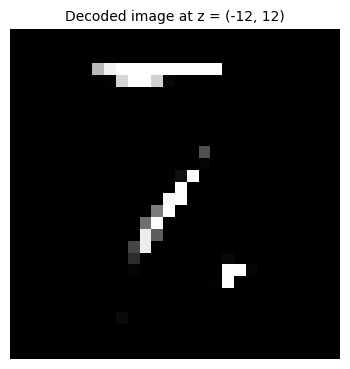

Minimum pixel value : 0.0000
Maximum pixel value : 1.0000
Mean pixel value    : 0.0350


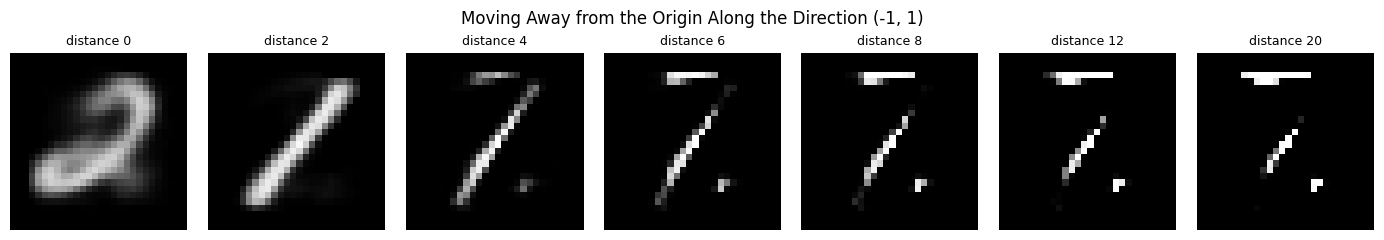

distance  0  ->  mean pixel = 0.1540,  max pixel = 0.8411
distance  2  ->  mean pixel = 0.0931,  max pixel = 0.9726
distance  4  ->  mean pixel = 0.0449,  max pixel = 0.9998
distance  6  ->  mean pixel = 0.0393,  max pixel = 1.0000
distance  8  ->  mean pixel = 0.0371,  max pixel = 1.0000
distance 12  ->  mean pixel = 0.0353,  max pixel = 1.0000
distance 20  ->  mean pixel = 0.0347,  max pixel = 1.0000


In [18]:
far_point = torch.tensor([[-12.0, 12.0]]).to(DEVICE)

with torch.no_grad():
    far_img = vae_model.decoder(far_point).cpu().view(28, 28)

fig, ax = plt.subplots(figsize=(3.6, 3.8))
ax.imshow(far_img, cmap="gray", vmin=0, vmax=1)
ax.set_title("Decoded image at z = (-12, 12)", fontsize=10)
ax.axis("off")
plt.tight_layout()
plt.show()

print("Minimum pixel value : %.4f" % far_img.min())
print("Maximum pixel value : %.4f" % far_img.max())
print("Mean pixel value    : %.4f" % far_img.mean())

distances = [0, 2, 4, 6, 8, 12, 20]
line_codes = torch.tensor([[-d / 2 ** 0.5 * 1.0, d / 2 ** 0.5 * 1.0] for d in distances], dtype=torch.float32).to(DEVICE)
with torch.no_grad():
    line_imgs = vae_model.decoder(line_codes).cpu().view(-1, 28, 28)

fig, axes = plt.subplots(1, len(distances), figsize=(14, 2.4))
for ax, img, d in zip(axes, line_imgs, distances):
    ax.imshow(img, cmap="gray", vmin=0, vmax=1)
    ax.set_title(f"distance {d}", fontsize=9)
    ax.axis("off")
fig.suptitle("Moving Away from the Origin Along the Direction (-1, 1)", fontsize=12)
plt.tight_layout()
plt.show()

for d, img in zip(distances, line_imgs):
    print(f"distance {d:>2}  ->  mean pixel = {img.mean():.4f},  max pixel = {img.max():.4f}")

## Written Observations

All statements below are based on the outputs produced by the cells above in this run (random seed 7).

### 1. Do similar digits form clusters?

Yes, to a large extent. In the VAE latent space (Step 12) the digits are not scattered randomly. The digit 1 sits at the top of the plot with its centre near (-0.04, 1.83), the digit 0 sits at the bottom left near (-0.59, -1.68), the digit 6 sits just to its right near (0.60, -1.28), and the digit 7 is in the upper right near (1.14, 0.71). The digits 4 and 9 lie next to each other on the right side, and the digits 3, 5, 8 and 2 lie on the left and in the middle. Digits that look alike are therefore placed close together. The normal autoencoder also groups digits (for example 1 at the top left and 0 at the bottom), but its clusters lie far apart with large empty regions between them and very long tails.

### 2. Are the clusters clearly separated?

Only partly. The digits 0, 1 and 6 form fairly clean groups, but the middle of the VAE plot is crowded. The centres of 2, 3, 5 and 8 are all within about one unit of each other, and 4 and 9 overlap strongly. This is what we would expect from a latent space with only two dimensions, since many digits must share a very small area. The nearest-neighbour test in Step 12 gives the same picture: the 5-NN accuracy is 0.799 for the VAE and 0.773 for the normal autoencoder. So the VAE is slightly better at keeping classes together, but neither model separates all ten digits cleanly in 2D. The difference of about 2.6 percentage points is small, and it comes from one run only.

### 3. How do the generated digits change when we move gradually through the latent space?

In the decoded grid (Step 13) the digit identity changes region by region. Along the top rows the image is a 1 in the centre, turning into a slanted 1 or 7-like stroke on the left and into a 7 on the right. Along the bottom rows a 0 on the left slowly becomes a 6 and then a 4-like shape on the far right. Along the middle rows the images change from 8 and 5 on the left, through 3 and 2 near the centre, to 4 and then 9 and 7 on the right. This order matches the positions of the digit centres printed in Step 12, so the grid and the scatter plot agree with each other.

### 4. Does the transition between generated images look smooth?

Mostly yes. Inside the region where the training data lies, neighbouring images in the grid look like small changes of each other. Strokes tilt, loops open or close, and one digit fades into the next without random noise in between. For example the 0 slowly gets narrower and tilts before it turns into a 6. The transitions are not perfect, though. Near the centre of the grid, at about (0, 0), the images become blurry and can look like a mixture of 2, 4 and 5, and the top right corner of the grid shows broken strokes. The KL divergence loss encourages the encoded points to fill the space around the origin, which is why most of the grid decodes to something digit-like. The blur in the middle appears because many different digits compete for that small area.

### 5. What happens at extreme points and outside the latent space?

The VAE points were mostly within about -4 to +4 (Step 12), with a mean close to (0, 0) and a standard deviation close to 1 in both directions. This is the effect of the KL term, and it explains why the decoder works well inside this region.

Step 14 shows that just beyond this region the decoder still produces a digit shape in several places, for example a clear 0 at (-5, -5) and (0, -5), and a thin 7 at (-5, 5) and (-3.5, 3.5). The image at (0, 5) is only a thin 1 stroke with a mean pixel value of 0.012. Other points give poor results: (5, 5) gives a few broken fragments, (-5, 0) gives an overlapping mixture that looks like 8 and 3, and (5, 0) gives a thick, blocky 7-like shape.

In Step 15 the point (-12, 12) is far from all the training data. The output is a sharp, high-contrast 7-like drawing made of a bar and a diagonal line with a small block, and it is not a natural handwritten digit. Its pixel values run from 0.0000 to 1.0000 with a low mean of 0.0350. When the point is moved away from the origin along the same direction, the image changes quickly up to a distance of about 4 to 6 and then hardly changes: the mean pixel value goes 0.1540, 0.0931, 0.0449, 0.0393, 0.0371, 0.0353 and 0.0347 for distances 0, 2, 4, 6, 8, 12 and 20. This shows that the decoder does not fail with noise. It simply keeps producing one fixed, saturated pattern, because the network was never trained for those inputs and its outputs saturate.

### 6. Comparison between the normal autoencoder and the VAE

| Property | Normal autoencoder | VAE |
|---|---|---|
| Latent range, dimension 1 | -17.87 to 24.08 | -3.92 to 3.71 |
| Latent range, dimension 2 | -17.78 to 13.45 | -3.81 to 3.19 |
| Average distance between digit centres | 6.35 | 1.67 |
| 5-NN accuracy on the test latent points | 0.773 | 0.799 |

The normal autoencoder has no rule about where points should go, so its codes spread over a wide area. The VAE keeps the codes compact and centred on zero, and this is what allows us to sample and decode any point near the origin and obtain a meaningful image.

### 7. Training behaviour

For the normal autoencoder, the binary cross entropy loss fell from 0.2171 in epoch 1 to 0.1735 in epoch 12, with the largest drop in the first two epochs. For the VAE, the loss per image fell from 46.063 to 33.929 in total and from 43.107 to 28.667 for the reconstruction part. The KL divergence went the opposite way and increased from 2.956 to 5.262. This is normal: at the start the encoder outputs are almost the same for every image, so the KL term is small. As the encoder learns to tell digits apart, it needs to place different digits at different positions, which costs more KL, but this is paid back by a better reconstruction. The test loss followed the training loss closely, finishing at 34.654 against 33.929 for training, so there is no strong sign of overfitting. The test loss was lowest at epoch 24 (34.559) and rose slightly in the last epoch, which is a small fluctuation.

The reconstructions in Step 11 are blurry versions of the originals, with a mean absolute pixel error of 0.0882 on the ten images shown. Most digits keep their identity, but two of the ten were rebuilt as a different digit: the 2 came back looking like a 5, and the 5 came back looking like a 4. This is a limit of using only two latent numbers to store each image.

## Conclusion

The experiment demonstrates that a **Variational Autoencoder (VAE)** produces a more structured and organized latent space compared to a standard autoencoder. The **KL divergence loss** helps keep the encoded points compact and centered around the origin, while similar digits tend to form nearby clusters. When a grid of latent points is decoded, the generated images show smooth transitions between different digits. However, some limitations are observed. With only two latent dimensions, digits such as **2, 3, 4, 5, 8, and 9** tend to overlap, resulting in less distinct representations. The reconstructed images can also appear blurry, and points far outside the learned latent region may produce unrealistic or distorted images.
